In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
import re
import string
from collections import Counter
import gc
import numpy as np
from opacus import PrivacyEngine
from opacus.layers import DPLSTM

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
imdb = load_dataset("imdb")
cola = {
    "train": load_dataset("shivkumarganesh/CoLA", split="train"),
}

np.random.seed(42)
imdb_indices = np.random.choice(len(imdb["train"]), size=len(imdb), replace=False)
cola_indices = np.random.choice(len(cola["train"]), size=6250, replace=False)

imdb_subset = imdb["train"].select(imdb_indices)
cola_subset = cola["train"].select(cola_indices)

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

counter = Counter()
for example in imdb["train"]:
    counter.update(tokenize(example["text"]))

min_freq = 3
vocab = {"<pad>": 0, "<unk>": 1}
for word, freq in counter.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)
inv_vocab = {v: k for k, v in vocab.items()}
PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

def text_pipeline(text, max_len=256):
    tokens = tokenize(text)[:max_len]
    bow_vector = torch.zeros(len(vocab), dtype=torch.float)
    for token in tokens:
        idx = vocab.get(token, UNK_IDX)
        bow_vector[idx] += 1
    return bow_vector

In [4]:
class TextDataset(Dataset):
    def __init__(self, hf_dataset, label_transform, text_field, max_len=256):
        self.data = hf_dataset
        self.label_transform = label_transform
        self.max_len = max_len
        self.text_field = text_field

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = text_pipeline(item[self.text_field], max_len=self.max_len)
        label = torch.tensor(self.label_transform(item["label"]), dtype=torch.long)
        return tokens, label

def collate_batch(batch):
    texts, labels = zip(*batch)
    padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return padded, torch.stack(labels)

In [5]:
train_loader_public = DataLoader(
    TextDataset(cola_subset, label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=True, collate_fn=collate_batch
)

train_loader_private = DataLoader(
    TextDataset(imdb_subset, label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=True, collate_fn=collate_batch
)

test_loader = DataLoader(
    TextDataset(imdb["test"], label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=False, collate_fn=collate_batch
)

In [6]:
class Model(nn.Module):
    def __init__(self, vocab_size, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(vocab_size, num_classes)

    def forward(self, x):
        return self.fc(x)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(len(vocab), num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
privacy_engine = PrivacyEngine()
gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


30

In [8]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs_1}]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/5]
Training loss 0.6477257679748535
Training accuracy 69.76 %
Testing loss 4.081057631494403
Testing accuracy 50.0 %
Epoch [2/5]
Training loss 0.6074817976570129
Training accuracy 70.224 %
Testing loss 5.024101825187429
Testing accuracy 50.0 %
Epoch [3/5]
Training loss 0.5907609831047058
Training accuracy 70.224 %
Testing loss 5.170459385626167
Testing accuracy 50.004 %
Epoch [4/5]
Training loss 0.5772784525299072
Training accuracy 70.24 %
Testing loss 5.205075216378421
Testing accuracy 50.004 %
Epoch [5/5]
Training loss 0.5652427555656433
Training accuracy 70.432 %
Testing loss 4.9084842509551345
Testing accuracy 50.004 %


In [9]:
epochs_2 = 10
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=target_delta,
    max_grad_norm=0.1,
)
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    epsilon = privacy_engine.get_epsilon(delta=target_delta)
    print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10]
Training loss 4.987661361694336
Training accuracy 33.333333333333336 %


/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/prv/prvs.py:67: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/prv/prvs.py:70: RuntimeWarning: divide by zero encountered in log
  t > np.log(1 - q),


Privacy Budget (epsilon, delta): (0.84, 1e-05)
Testing loss 4.930231045672372
Testing accuracy 50.004 %
Epoch [2/10]
Training loss 4.993347644805908
Training accuracy 33.333333333333336 %
Privacy Budget (epsilon, delta): (1.23, 1e-05)
Testing loss 4.950599186929986
Testing accuracy 50.004 %
Epoch [3/10]
Training loss 4.994684219360352
Training accuracy 33.333333333333336 %
Privacy Budget (epsilon, delta): (1.53, 1e-05)
Testing loss 4.959954813784435
Testing accuracy 50.004 %
Epoch [4/10]
Training loss 4.970509052276611
Training accuracy 33.333333333333336 %
Privacy Budget (epsilon, delta): (1.80, 1e-05)
Testing loss 4.979677325588391
Testing accuracy 50.004 %
Epoch [5/10]
Training loss 4.972471237182617
Training accuracy 33.333333333333336 %
Privacy Budget (epsilon, delta): (2.03, 1e-05)
Testing loss 4.987051233336329
Testing accuracy 50.004 %
Epoch [6/10]
Training loss 4.95377779006958
Training accuracy 33.333333333333336 %
Privacy Budget (epsilon, delta): (2.25, 1e-05)
Testing loss 5

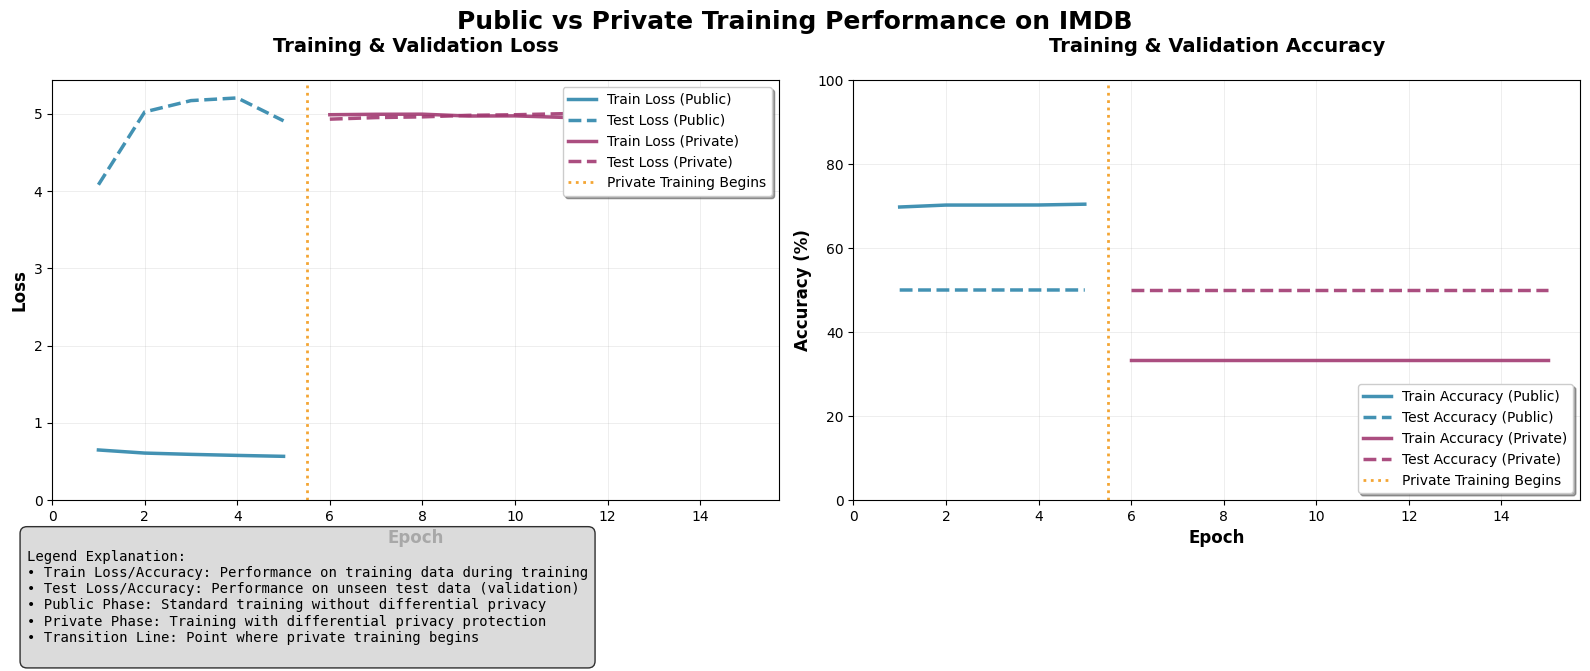

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

# Set up the figure with improved styling
plt.rcParams.update({'font.size': 10})  # Set default font size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define colors for consistency
public_color = '#2E86AB'    # Blue
private_color = '#A23B72'   # Red/Purple
transition_color = '#F18F01' # Orange

# --- Loss Plot ---
ax1.plot(public_epochs, train_losses, color=public_color, linewidth=2.5, 
         label='Train Loss (Public)', alpha=0.9)
ax1.plot(public_epochs, test_losses, color=public_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Public)', alpha=0.9)

ax1.plot(private_epochs, train_losses_2, color=private_color, linewidth=2.5, 
         label='Train Loss (Private)', alpha=0.9)
ax1.plot(private_epochs, test_losses_2, color=private_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Private)', alpha=0.9)

# Add transition line with better styling
ax1.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
# Note: Your accuracy values are already in percentage (0-100), so don't multiply by 100
ax2.plot(public_epochs, train_accuracies, color=public_color, 
         linewidth=2.5, label='Train Accuracy (Public)', alpha=0.9)
ax2.plot(public_epochs, test_accuracies, color=public_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Public)', alpha=0.9)

ax2.plot(private_epochs, train_accuracies_2, color=private_color, 
         linewidth=2.5, label='Train Accuracy (Private)', alpha=0.9)
ax2.plot(private_epochs, test_accuracies_2, color=private_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Private)', alpha=0.9)

# Add transition line
ax2.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Add overall title with more spacing
fig.suptitle('Public vs Private Training Performance on IMDB', 
             fontsize=18, fontweight='bold', y=0.95)

# Improve layout with space for glossary
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # More space for the glossary at bottom

# Add glossary/legend explanation
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
• Public Phase: Standard training without differential privacy
• Private Phase: Training with differential privacy protection
• Transition Line: Point where private training begins
"""

# Add glossary as text box
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure in high quality
# plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')